In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Binary Classification

## Generate Synthetic Datasets

In [ ]:
rng = np.random.default_rng(seed=0)
N = 500
D = 2


X1 = rng.normal(loc=np.array([0, 0]), scale=np.ones(2), size=(N, D))
X2 = rng.normal(loc=np.array([5,5]), scale=np.ones(2), size=(N, D))

plt.scatter(X1[:, 0], X1[:, 1], color="r", label="Class 1")
plt.scatter(X2[:, 0], X2[:, 1], color="b", label="Class 2")
plt.title("Generated Synthetic Data")
plt.legend()

## Test Train Split

In [ ]:
Y1 = np.zeros(shape=(N, 1))
Y2 = np.ones(shape=(N, 1))
Y = np.vstack([Y1, Y2])
X = np.vstack([X1, X2])

data = np.hstack([X, Y])
rng.shuffle(data)

X_train, Y_train = data[:800, :2], data[:800, 2].reshape(-1, 1)
X_test, Y_test = data[800:, :2], data[800:, 2].reshape(-1, 1)
print(f"Train shapes: X - {X_train.shape}, Y - {Y_train.shape}")
print(f"Test shapes: X - {X_test.shape}, Y - {Y_test.shape}")

## Logisitic Regression (Numpy)

In [ ]:
epochs: int = 30
batch_size: int = 32
learning_rate: float = 0.01

W = rng.normal(size=(2, 1)) * 0.01
B = rng.normal(size= 1) * 0.01

for _ in range(epochs):
    for start in range(0, X_train.shape[0], batch_size):
        end = min(X_train.shape[0], start + batch_size)
        X, Y = X_train[start:end], Y_train[start:end]

        # forward pass
        z = X @ W + B
        
        # backprop
        yhat = 1 / (1 + np.exp(-z)) # Sigmoid operation
        error = (yhat - Y) / X.shape[0]
        grad = X.T @ error

        W -= learning_rate * grad
        B -= learning_rate * error.sum()

In [ ]:
# plot 
ypred = X_test @ W + B
ypred = 1 / (1 + np.exp(-ypred))

pred_labels = (ypred >= 0.5).astype(int)
accuracy = (pred_labels == Y_test).sum() / Y_test.shape[0]
print("acccuracy:", accuracy)
print("incorrects:", (pred_labels != Y_test).sum())

# ground truth values
X_test1 = X_test[Y_test[:, 0] == 0]
X_test2 = X_test[Y_test[:, 0] == 1]
plt.scatter(X_test1[:, 0], X_test1[:, 1], label="Class 0", color="r")
plt.scatter(X_test2[:, 0], X_test2[:, 1], label="Class 1", color="b")

#predcited values
X_pred1 = X_test[ypred[:, 0] == 0]
X_pred1 = X_test[ypred[:, 0] == 1]
plt.scatter(X_test1[:, 0], X_test1[:, 1], label="Class 0 predicted", marker="1")
plt.scatter(X_test2[:, 0], X_test2[:, 1], label="Class 1 predicted", marker="2")
plt.legend()
# plt.scatter()


## Logistic Regression (PyTorch)

In [ ]:
epochs = 30
batch_size = 32
learning_rate = 0.01

X_train_ = torch.tensor(X_train, dtype=torch.float32)
Y_train_ = torch.tensor(Y_train, dtype=torch.float32).reshape(-1, 1)
W = torch.randn(size=(2, 1), dtype=torch.float32) * 0.01
B = torch.randn((), dtype=torch.float32) * 0.01

for _ in range(epochs):
    for start in range(0, X_train_.shape[0], batch_size):
        end = min(start + batch_size, X_train_.shape[0])
        X, Y = X_train_[start:end], Y_train_[start:end]

        # forward pass
        z = X @ W + B
        yhat = torch.sigmoid(z)

        # backprop
        d_error = (yhat - Y) / X.shape[0] # (N, 1)
        d_wgrad =  X.T @ d_error # (D, 1)
        d_bgrad = d_error.sum()

        # update
        W -= learning_rate * d_wgrad
        B -= learning_rate * d_bgrad



In [ ]:
# plot 
ypred = torch.tensor(X_test, dtype=torch.float32) @ W  + B
ypred = torch.sigmoid(ypred)

ypred_labels = torch.tensor((ypred >= 0.5), dtype=torch.int)
accuracy = (ypred_labels == torch.tensor(Y_test, dtype=torch.int)).sum() / Y_test.shape[0]
print("accuracy:", accuracy)

## Logistic Regression (PyTorch Autograd)

In [ ]:
import torch.nn.functional as F

X_train_ = torch.tensor(X_train, dtype=torch.float32)
Y_train_ = torch.tensor(Y_train, dtype=torch.float32).reshape(-1, 1)
W = torch.randn(size=(2, 1), dtype=torch.float32, requires_grad=True)
B = torch.randn((), dtype=torch.float32, requires_grad=True)

epochs = 100
batch_size = 32
learning_rate = torch.tensor(0.01, dtype=torch.float32)

for _ in range(epochs):
    for start in range(0, X_train_.shape[0], batch_size):
        end = min(X_train_.shape[0], start + batch_size)
        X, Y = X_train_[start:end], Y_train_[start:end]

        # forward pass
        z = X @ W + B
        loss = F.binary_cross_entropy_with_logits(z, Y)

        loss.backward()

        with torch.no_grad():
            W -= learning_rate * W.grad
            B -= learning_rate * B.grad

            W.grad.zero_()
            B.grad.zero_()



In [ ]:
# plot 
ypred = torch.tensor(X_test, dtype=torch.float32) @ W  + B
ypred = torch.sigmoid(ypred)

ypred_labels = torch.tensor((ypred >= 0.5), dtype=torch.int)
accuracy = (ypred_labels == torch.tensor(Y_test, dtype=torch.int)).sum() / Y_test.shape[0]
print("accuracy:", accuracy)

# Multi-Class Classification

## Generate Synthetic Data & Test-Train Split

(600, 3)


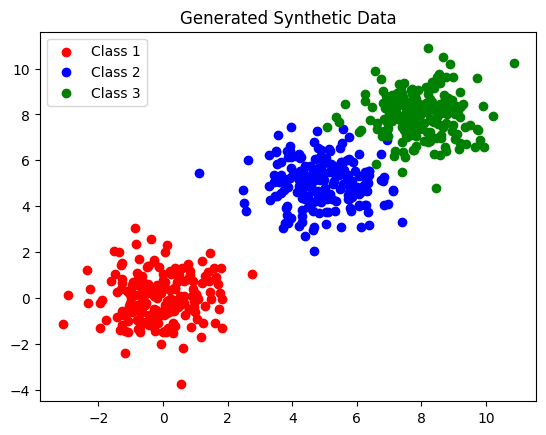

In [6]:
rng = np.random.default_rng(seed=0)
N = 200
D = 2


X1 = rng.normal(loc=np.array([0, 0]), scale=np.ones(2), size=(N, D))
X2 = rng.normal(loc=np.array([5,5]), scale=np.ones(2), size=(N, D))
X3 = rng.normal(loc=np.array([8,8]), scale=np.ones(2), size=(N, D))

plt.scatter(X1[:, 0], X1[:, 1], color="r", label="Class 1")
plt.scatter(X2[:, 0], X2[:, 1], color="b", label="Class 2")
plt.scatter(X3[:, 0], X3[:, 1], color="g", label="Class 3")
plt.title("Generated Synthetic Data")
plt.legend()


Y1 = np.zeros((N,1))
Y2 = np.ones((N,1))
Y3 = np.ones((N,1)) * 2
X = np.vstack([X1, X2, X3])
Y = np.vstack([Y1, Y2, Y3])
data = np.hstack([X, Y])
print(data.shape)

In [60]:
rng.shuffle(data)
X_train, Y_train = data[:500, :2], data[:500, 2].reshape(-1, 1)
X_test, Y_test = data[500:, :2], data[500:, 2].reshape(-1, 1)
print(f"Train Shapes: X {X_train.shape}, Y {Y_train.shape}")
print(f"Test Shapes: X {X_test.shape}, Y {Y_test.shape}")

Train Shapes: X (500, 2), Y (500, 1)
Test Shapes: X (100, 2), Y (100, 1)


## Numpy

In [ ]:
epochs = 100
batch_size = 16
learning_rate = 0.01
W = rng.normal(size=(2, 3)) * 0.01
B = rng.normal(size=(1, 3)) * 0.01

def softmax(x: np.ndarray) -> np.ndarray:
    z = np.exp(x - x.max(axis=1, keepdims=True))
    z /= (z.sum(axis=1, keepdims=True) + 1e-6)
    return z


for _ in range(epochs):
    for start in range(0, X_train.shape[0], batch_size):
        end = min(start + batch_size, X_train.shape[0])
        X, Y = X_train[start:end], Y_train[start:end]
        Y_one_hot = np.eye(3)[Y.astype(int)][:, 0, :]
        
        # forward pass
        z = X @ W + B # (N, k)
        yhat = softmax(z) # (N, k)

        # backprop
        d_error = (yhat - Y_one_hot) / X.shape[0] # (N, k)
        d_wgrad = X.T @ d_error 
        d_bgrad = d_error.sum(axis=0, keepdims=True)

        # update weights
        W -= learning_rate * d_wgrad
        B -= learning_rate * d_bgrad


In [79]:
ypred = X_test @ W + B
ypred = softmax(ypred)
ypred = np.argmax(ypred, axis=1).reshape(-1, 1)

accuracy = (ypred == Y_test).astype(int)
accuracy = accuracy.sum() / Y_test.shape[0]
print(accuracy)

1.0


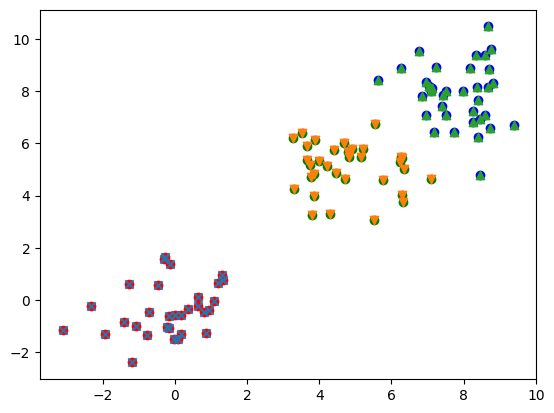

In [81]:
# plot 
X1_test = X_test[Y_test[:, 0] == 0]
X2_test = X_test[Y_test[:, 0] == 1]
X3_test = X_test[Y_test[:, 0] == 2]

plt.scatter(X1_test[:, 0], X1_test[:, 1], color="r", label="Class 0")
plt.scatter(X2_test[:, 0], X2_test[:, 1], color="g", label="Class 1")
plt.scatter(X3_test[:, 0], X3_test[:, 1], color="b", label="Class 2")

X1_pred = X_test[ypred[:, 0] == 0]
X2_pred = X_test[ypred[:, 0] == 1]
X3_pred = X_test[ypred[:, 0] == 2]

plt.scatter(X1_pred[:, 0], X1_pred[:, 1], marker="x", label="Class 0 predicted")
plt.scatter(X2_pred[:, 0], X2_pred[:, 1], marker="v", label="Class 1 predicted")
plt.scatter(X3_pred[:, 0], X3_pred[:, 1], marker="^", label="Class 2 predicted")

## PyTorch 

In [ ]:
import torch.nn.functional as F

epochs = 100
batch_size = 16
learning_rate = 0.01

X_train_  = torch.tensor(X_train, dtype=torch.float32)
Y_train_  = torch.tensor(Y_train, dtype=torch.long)
# W = torch.randn(size=(2, 3), dtype=torch.float32) * 0.01
# B = torch.randn(size=(1, 3), dtype=torch.float32) * 0.01
# torch autograd
W = (torch.randn(size=(2, 3), dtype=torch.float32) * 0.01).requires_grad_()
B = (torch.randn(size=(1, 3), dtype=torch.float32) * 0.01).requires_grad_()

for _ in range(epochs):
    for start in range(0, X_train_.shape[0], batch_size):
        end = min(start + batch_size, X_train_.shape[0])
        X, Y = X_train_[start:end], Y_train_[start:end]
        # Y_one_hot = torch.eye(3)[Y][:, 0, :]
        # assert Y_one_hot.shape == (X.shape[0], 3), "One-hot vector shapes mismatch"

        # forward pass
        z = X @ W + B
        # yhat = torch.softmax(z, dim=1) # (N, K)

        # torch autograd
        loss = F.cross_entropy(z, Y.squeeze(1))
        loss.backward()

        with torch.no_grad():
            W -= learning_rate * W.grad
            B -= learning_rate * B.grad

            W.grad.zero_()
            B.grad.zero_()


        # backprop
        # d_error = (yhat - Y_one_hot) / X.shape[0] # (N, K)
        # d_wgrad = X.T @ d_error # (D, K)
        # d_bgrad = d_error.sum(dim=0, keepdim=True) # (1, K)

        # updates 
        # W -= learning_rate * d_wgrad
        # B -= learning_rate * d_bgrad


In [99]:
ypred = torch.tensor(X_test, dtype=torch.float32) @ W + B
ypred = torch.softmax(ypred, dim=1)
ypred_labels = torch.argmax(ypred, dim=1)

mask = ypred_labels == torch.tensor(Y_test.squeeze(), dtype=torch.int)
accuracy = torch.mean(mask.to(torch.float))
print("accuracy:", accuracy)

accuracy: tensor(1.)
